# LOAD LIBRARIES

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [37]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'time_blocks_eliza'
N_FOLDS = 10
LOG_TRANSFORM = True
UNDERSAMPLE = False

# LOAD DATA

In [38]:
data_main = fluxes = load_parquet(filepath=r"111.1_GapFillingDataset.parquet", sanitize_timestamp=False)
data_main = data_main.loc[START_DATE:END_DATE].copy()

data_main

Loaded .parquet file 111.1_GapFillingDataset.parquet (0.089 seconds).


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff8h,ts_0.3_gfXG_diff16h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff8h,wfps_0.05_gfXG_diff16h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff8h,wfps_0.15_gfXG_diff16h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff8h,wfps_0.3_gfXG_diff16h,wfps_0.3_gfXG_diff24h,cropN_diff8h,cropN_diff16h,cropN_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.7,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 00:00:00,2.969070,7.7,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 08:00:00,20.423914,1.3,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.0,0.0,...,0.470151,NaN,NaN,0.108514,NaN,NaN,-0.337935,NaN,NaN,0.073253,NaN,NaN,0.001213,NaN,NaN
2023-11-17 08:00:00,20.423914,1.3,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.0,0.0,...,0.470151,NaN,NaN,0.108514,NaN,NaN,-0.337935,NaN,NaN,0.073253,NaN,NaN,0.001584,NaN,NaN
2023-11-17 16:00:00,-1.671137,0.8,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.0,0.0,...,0.146294,0.616444,NaN,-1.623485,-1.514972,NaN,-0.049745,-0.387679,NaN,-0.527939,-0.454685,NaN,0.001240,0.002453,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 00:00:00,13.803417,0.0,18.172917,99,19.623379,20.864491,20.419120,33.136657,46.159823,42.875132,16,27,60,0.0,0.0,...,-0.100024,0.444722,0.127366,-0.954191,-2.638742,-2.947887,-0.421852,-0.940859,-1.465733,0.042939,-0.075518,-0.170882,0.000000,0.000000,0.0
2024-08-21 08:00:00,79.888271,0.0,19.366042,115,20.788310,20.419259,19.986018,31.746818,45.525360,42.701680,17,28,60,0.0,0.0,...,-0.433102,-0.533126,0.011620,-1.389839,-2.344030,-4.028581,-0.634462,-1.056314,-1.575321,-0.173452,-0.130513,-0.248970,0.000000,0.000000,0.0
2024-08-21 08:00:00,79.888271,0.0,19.366042,115,20.788310,20.419259,19.986018,31.746818,45.525360,42.701680,17,28,60,0.0,0.0,...,-0.433102,-0.533126,0.011620,-1.389839,-2.344030,-4.028581,-0.634462,-1.056314,-1.575321,-0.173452,-0.130513,-0.248970,0.000000,0.000000,0.0


# CLEAN DATA

In [39]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}\n')

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

data

The target variable is FN2O_L3.3_CUT_50_QCF0



,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff8h,ts_0.3_gfXG_diff16h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff8h,wfps_0.05_gfXG_diff16h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff8h,wfps_0.15_gfXG_diff16h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff8h,wfps_0.3_gfXG_diff16h,wfps_0.3_gfXG_diff24h,cropN_diff8h,cropN_diff16h,cropN_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.7,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 00:00:00,2.969070,7.7,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 08:00:00,20.423914,1.3,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.0,0.0,...,0.470151,NaN,NaN,0.108514,NaN,NaN,-0.337935,NaN,NaN,0.073253,NaN,NaN,0.001584,NaN,NaN
2023-11-17 16:00:00,-1.671137,0.8,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.0,0.0,...,0.146294,0.616444,NaN,-1.623485,-1.514972,NaN,-0.049745,-0.387679,NaN,-0.527939,-0.454685,NaN,0.001619,0.003203,NaN
2023-11-18 08:00:00,30.765112,0.1,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.0,0.0,...,-0.201127,-0.594716,-0.448422,-0.777887,-2.476497,-4.099982,-0.568643,-1.013480,-1.063225,-2.107142,-3.361950,-3.889889,0.001691,0.003345,0.004965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:00:00,63.311470,0.0,19.338125,67,21.443587,20.557315,19.974397,35.775399,47.100681,42.950650,16,27,60,0.0,0.0,...,-0.317357,-0.631506,-0.188450,-0.309145,-0.835442,-1.728829,-0.524874,-1.019396,-1.835471,-0.095364,-0.048396,0.117995,0.000000,0.000000,0.000000
2024-08-20 16:00:00,15.368005,0.0,21.057083,83,22.740416,22.017685,20.519144,34.090848,46.581675,42.832193,16,27,60,0.0,0.0,...,0.544747,0.227390,-0.086760,-1.684551,-1.993696,-2.519993,-0.519007,-1.043881,-1.538403,-0.118457,-0.213821,-0.166852,0.000000,0.000000,0.000000
2024-08-21 00:00:00,13.803417,0.0,18.172917,99,19.623379,20.864491,20.419120,33.136657,46.159823,42.875132,16,27,60,0.0,0.0,...,-0.100024,0.444722,0.127366,-0.954191,-2.638742,-2.947887,-0.421852,-0.940859,-1.465733,0.042939,-0.075518,-0.170882,0.000000,0.000000,0.000000


# SELECT FEATURES

In [40]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'wfps_0.05_gfXG_diff16h',
# 'wfps_0.15_gfXG_lag16h',
# 'ts_0.05_gfXG_diff8h',
# 'n_decay_timed',
# 'timesince_fert',
# 'cropN_diff8h'
# ]

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,wfps_0.05_gfXG,timesince_soil_preparation,n_decay_linear,n_decay_logistic,n_decay_lognormal,GPP_NT_CUT_50_gfXG_QCF_lag24h,ts_0.3_gfXG_lag24h,wfps_0.15_gfXG_lag16h,wfps_0.3_gfXG_lag16h,ts_0.05_gfXG_diff8h,wfps_0.05_gfXG_diff16h,wfps_0.15_gfXG_diff24h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2023-11-17 00:00:00,49.895811,30,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197910
2023-11-17 00:00:00,49.895811,30,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.163722
2023-11-17 08:00:00,50.004324,31,0.0,0.0,0.0,NaN,NaN,NaN,NaN,-1.895046,NaN,NaN,-0.012439
2023-11-17 16:00:00,48.380839,31,0.0,0.0,0.0,NaN,NaN,56.984464,47.046478,-0.335163,-1.514972,NaN,0.121575
2023-11-18 08:00:00,45.904342,32,0.0,0.0,0.0,20.423914,8.046294,56.596784,46.591793,-0.104777,-2.476497,-1.063225,0.292255
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:00:00,35.775399,16,0.0,0.0,0.0,37.660038,20.162847,48.120078,42.999045,2.068051,-0.835442,-1.835471,3.998577
2024-08-20 16:00:00,34.090848,16,0.0,0.0,0.0,6.573371,20.605904,47.625556,43.046014,1.296829,-1.993696,-1.538403,2.381710
2024-08-21 00:00:00,33.136657,16,0.0,0.0,0.0,9.591480,20.291754,47.100681,42.950650,-3.117037,-2.638742,-1.465733,1.869039


# IMBALANCE HANDLING

## UNDER SAMPLING

In [41]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling');
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

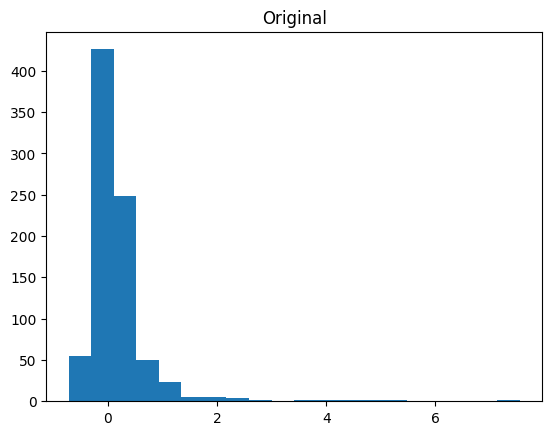

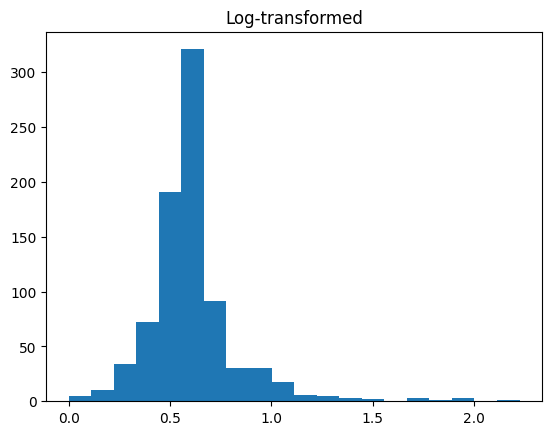

Log-tranformed
FN2O_L3.3_CUT_50_QCF0 was log-transformed


,wfps_0.05_gfXG,timesince_soil_preparation,n_decay_linear,n_decay_logistic,n_decay_lognormal,GPP_NT_CUT_50_gfXG_QCF_lag24h,ts_0.3_gfXG_lag24h,wfps_0.15_gfXG_lag16h,wfps_0.3_gfXG_lag16h,ts_0.05_gfXG_diff8h,wfps_0.05_gfXG_diff16h,wfps_0.15_gfXG_diff24h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2023-11-17 00:00:00,49.895811,30,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.651140
2023-11-17 00:00:00,49.895811,30,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.442179
2023-11-17 08:00:00,50.004324,31,0.0,0.0,0.0,NaN,NaN,NaN,NaN,-1.895046,NaN,NaN,0.534958
2023-11-17 16:00:00,48.380839,31,0.0,0.0,0.0,NaN,NaN,56.984464,47.046478,-0.335163,-1.514972,NaN,0.610521
2023-11-18 08:00:00,45.904342,32,0.0,0.0,0.0,20.423914,8.046294,56.596784,46.591793,-0.104777,-2.476497,-1.063225,0.699164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:00:00,35.775399,16,0.0,0.0,0.0,37.660038,20.162847,48.120078,42.999045,2.068051,-0.835442,-1.835471,1.743688
2024-08-20 16:00:00,34.090848,16,0.0,0.0,0.0,6.573371,20.605904,47.625556,43.046014,1.296829,-1.993696,-1.538403,1.411359
2024-08-21 00:00:00,33.136657,16,0.0,0.0,0.0,9.591480,20.291754,47.100681,42.950650,-3.117037,-2.638742,-1.465733,1.277833


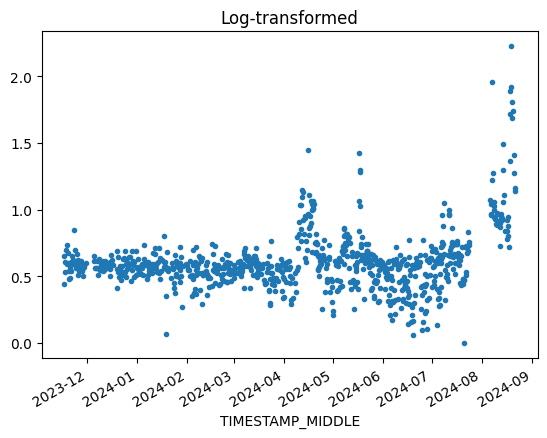

In [42]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (4 records on average) splits for cross-validation



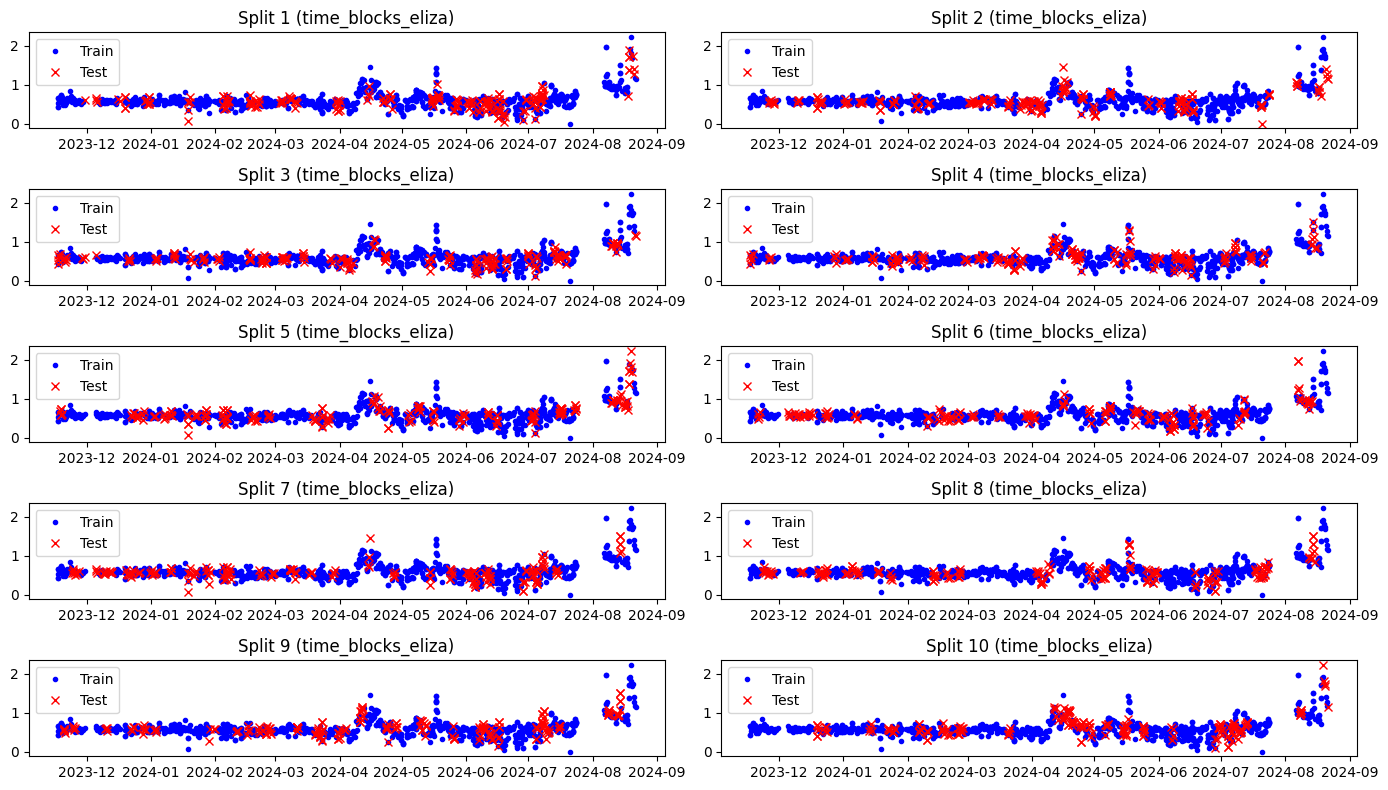

In [43]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 4 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [44]:
# Convert cross-val splits into PredefinedSplit format to be able to use them in GridSearchCV
test_fold = np.full(len(data), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(cross_val_splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
predefined_cv = PredefinedSplit(test_fold)

param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 300, 500], # Similar to XGBoost
        'max_depth': [3, 5, 10, 15], # Controls tree depth
        'min_samples_split': [2, 5, 10], # Similar to min_child_weight
        'min_samples_leaf': [1, 3, 5], # Controls leaf size
        'max_features': [0.4, 0.6, 0.8, 1.0], # Similar to colsample_bytree
    },
    'XGBoost': {
        'n_estimators': [50, 100, 300, 500],
        'gamma': [0, 0.2, 0.4],
        'max_depth': [3, 5, 10, 15],
        'learning_rate': [0.001, 0.005, 0.01, 0.05],
        'subsample': [0.65, 0.75, 1],
        'colsample_bytree': [0.4, 0.6, 0.8, 1],
        'min_child_weight': [2, 5, 10]
    }
}

model_class = RandomForestRegressor if MODEL_TYPE == 'RandomForest' else XGBRegressor
param_grid = param_grids[MODEL_TYPE]
model = model_class(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=predefined_cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(data[selected_features], data[TARGET])

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.75}


# EXPORT 

In [45]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(grid_search.best_params_, f)

# **End of notebook**

In [46]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-08 15:52:52
